1
2
3
4
5
6
1
2
3
4
5
6


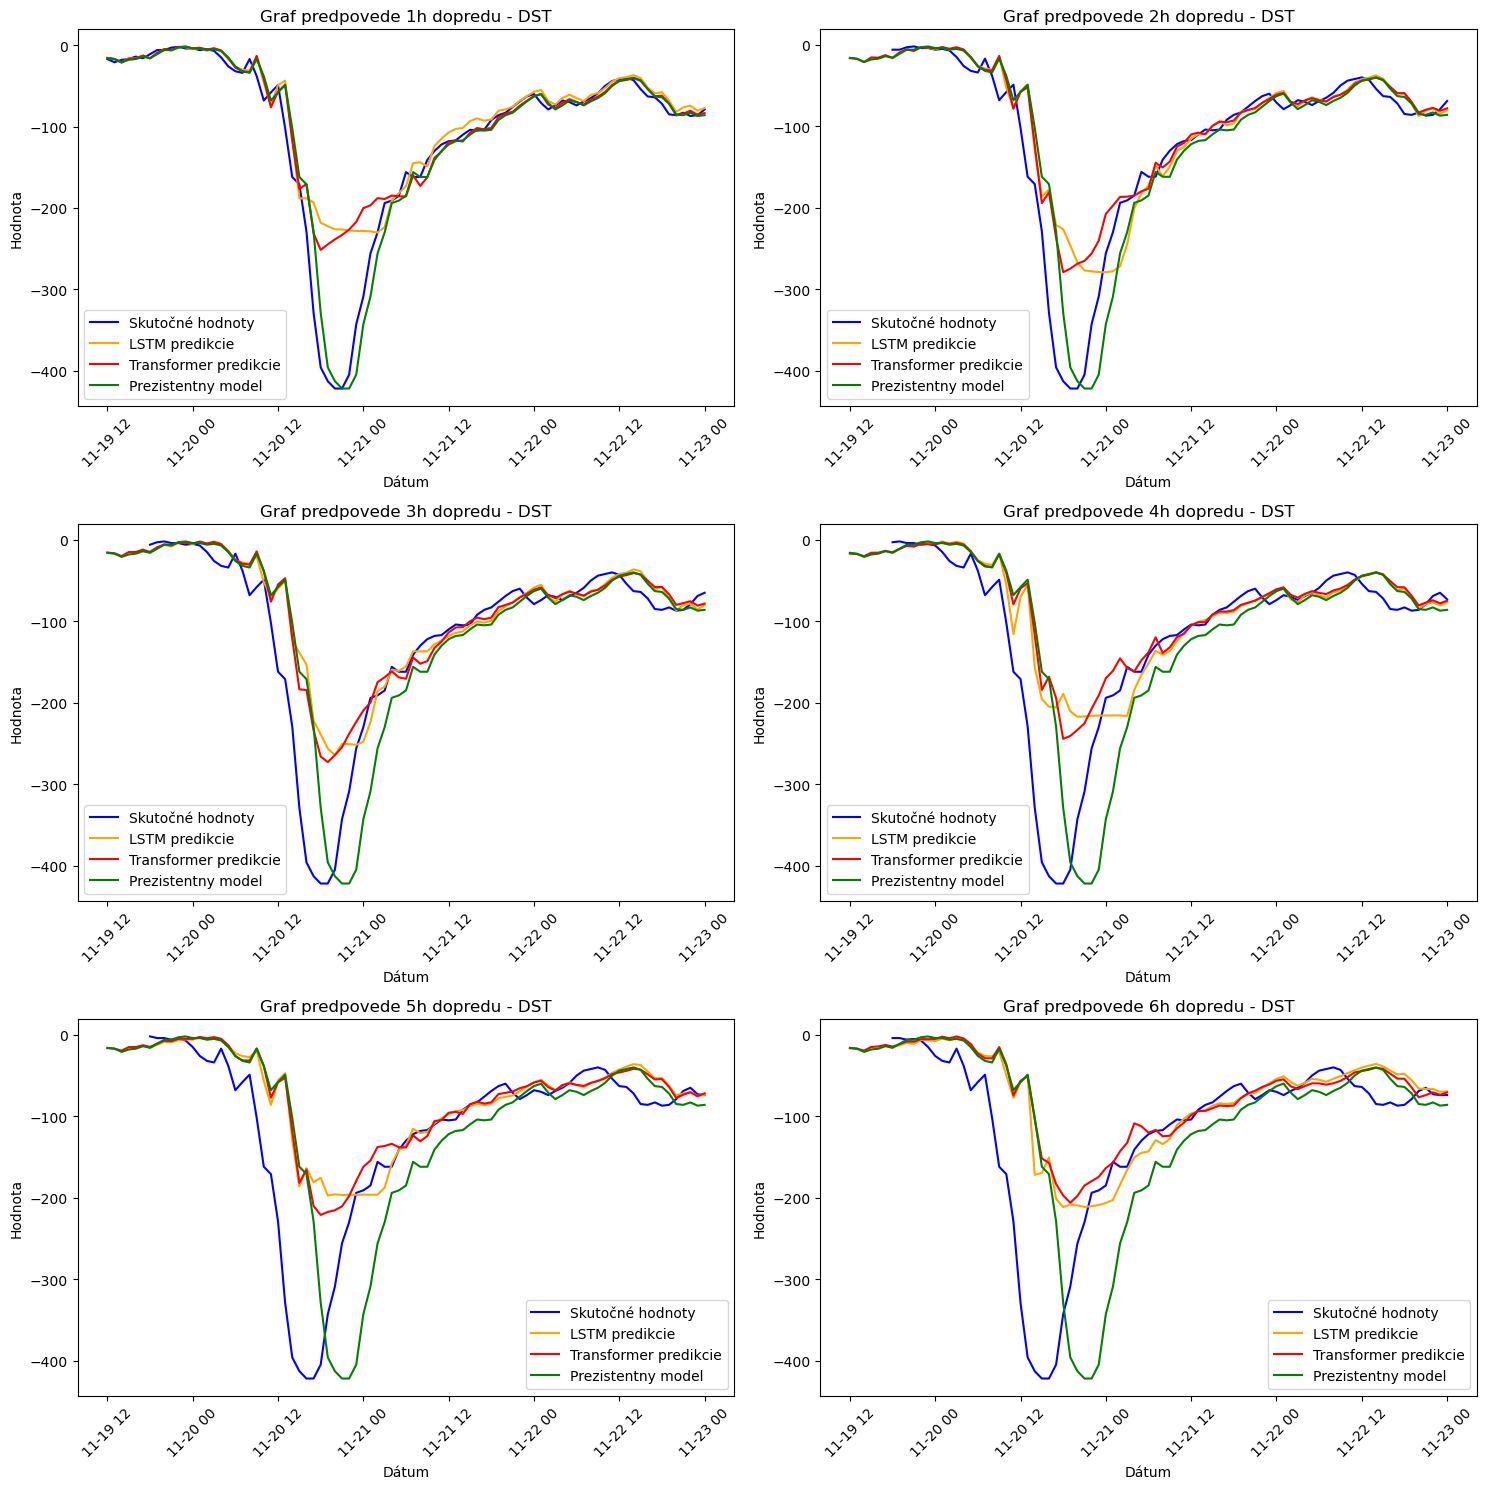

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the date range
start_date = '2003-11-19'
end_date = '2003-11-23'

# Function to load and filter dataframes from CSV files
def load_dataframes(extension):
    dataframes = []
    for i in range(1, 7):
        filename = f'prediction_comparison_DST+{i}{extension}.csv'
        df = pd.read_csv(filename, parse_dates=['time'])
        # Filter by the specified date range
        df = df[(df['time'] >= start_date) & (df['time'] <= end_date)]
        dataframes.append(df)
        print(i)
    return dataframes

# Load data for transformer predictions
dataframes_transformer = load_dataframes('_transf')

# Load data for original predictions
dataframes = load_dataframes('_LSTM')

# Plotting the combined graph
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(dataframes[i]['time'], dataframes[i]['y_true'], label='Skutočné hodnoty', color="blue")
    ax.plot(dataframes[i]['time'], dataframes[i]['y_predict'], label='LSTM predikcie', color="orange")
    ax.plot(dataframes_transformer[i]['time'], dataframes_transformer[i]['y_predict'], label='Transformer predikcie', color="red")
    ax.plot(dataframes_transformer[i]['time'], dataframes_transformer[i]['y_persistance'], label = 'Prezistentny model', color="green")
    ax.set_title(f'Graf predpovede {i+1}h dopredu - DST')
    ax.set_xlabel('Dátum')
    ax.set_ylabel('Hodnota')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("graf_BP.png")
plt.show()
